## Import all Libraries

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

### Load Dataset

In [83]:
df = pd.read_csv("Smart_Outcome_Predictor.csv")

In [84]:
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [85]:
df.shape

(5200, 19)

In [86]:
df.columns

Index(['student_id', 'age', 'country_region', 'device_type',
       'education_background', 'course_level', 'course_category',
       'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours',
       'videos_watched', 'quiz_attempts', 'assignments_submitted',
       'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status',
       'final_score'],
      dtype='str')

### About Dataset

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   str    
 3   device_type            5200 non-null   str    
 4   education_background   5200 non-null   str    
 5   course_level           5200 non-null   str    
 6   course_category        5200 non-null   str    
 7   course_start_date      5200 non-null   str    
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null   int64  
 15  avg_quiz_score 

In [88]:
df.describe()

,student_id,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
count,5200.000000,5200.000000,5200.000000,5200.000000,5088.000000,5200.000000,5200.000000,5200.000000,5200.000000,5119.000000,5120.000000,5200.000000,5200.000000
mean,702600.500000,24.339615,26.621538,19.121923,18.216156,25.852885,6.995769,3.835769,1.585577,66.842626,0.847189,0.375385,74.821615
std,1501.255031,5.578864,15.007731,10.726708,10.734114,17.720493,2.568017,1.951802,1.270640,13.813992,0.113545,0.484269,13.531829
min,700001.000000,16.000000,1.000000,1.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.313000,0.000000,35.200000
25%,701300.750000,20.000000,14.000000,11.000000,10.300000,13.000000,5.000000,2.000000,1.000000,57.500000,0.768750,0.000000,64.700000
50%,702600.500000,24.000000,27.000000,17.000000,16.100000,23.000000,7.000000,4.000000,1.000000,66.900000,0.855000,0.000000,74.100000
75%,703900.250000,28.000000,40.000000,25.000000,23.800000,35.000000,9.000000,5.000000,2.000000,76.200000,0.942000,1.000000,84.900000
max,705200.000000,45.000000,52.000000,94.000000,76.800000,158.000000,20.000000,12.000000,8.000000,100.000000,1.000000,1.000000,100.000000


### Check null value

In [89]:
df.isnull().sum()

student_id                 0
age                        0
country_region             0
device_type                0
education_background       0
course_level               0
course_category            0
course_start_date          0
week_of_year               0
sessions                   0
time_spent_hours         112
videos_watched             0
quiz_attempts              0
assignments_submitted      0
forum_posts                0
avg_quiz_score            81
attendance_rate           80
completion_status          0
final_score                0
dtype: int64

In [90]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
5195    False
5196    False
5197    False
5198    False
5199    False
Length: 5200, dtype: bool

### Fill Numerical Column

In [91]:
num_cols = df.select_dtypes(include=np.number).columns

In [92]:
num_cols

Index(['student_id', 'age', 'week_of_year', 'sessions', 'time_spent_hours',
       'videos_watched', 'quiz_attempts', 'assignments_submitted',
       'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status',
       'final_score'],
      dtype='str')

In [93]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

### Fill Catagorical Column

In [94]:
cat_cols = df.select_dtypes(include='object').columns

C:\Users\Shyamdev verma\AppData\Local\Temp\ipykernel_4244\2176772794.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [95]:
cat_cols

Index(['country_region', 'device_type', 'education_background', 'course_level',
       'course_category', 'course_start_date'],
      dtype='str')

In [96]:
cat_imputer = SimpleImputer(strategy='most_frequent')

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [97]:
df.isnull().sum()

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64

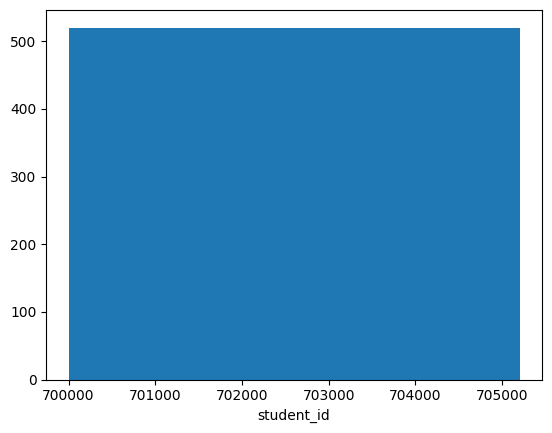

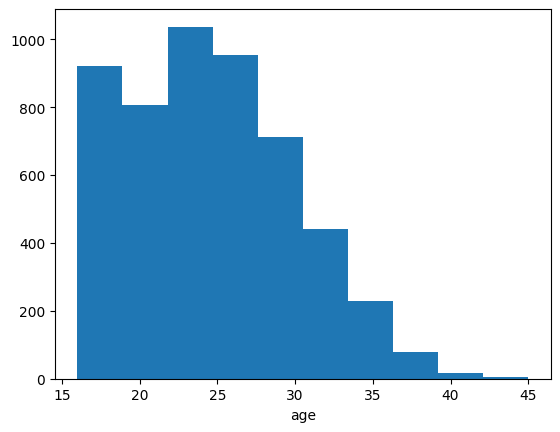

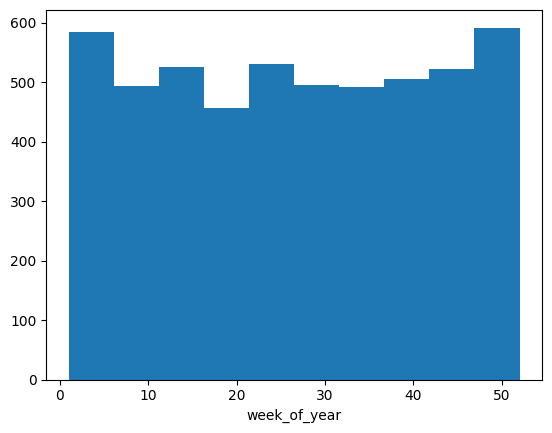

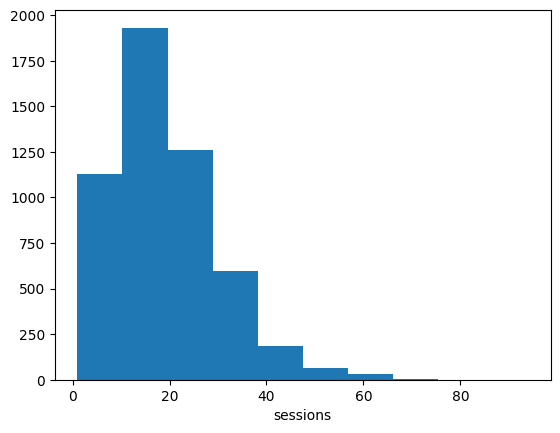

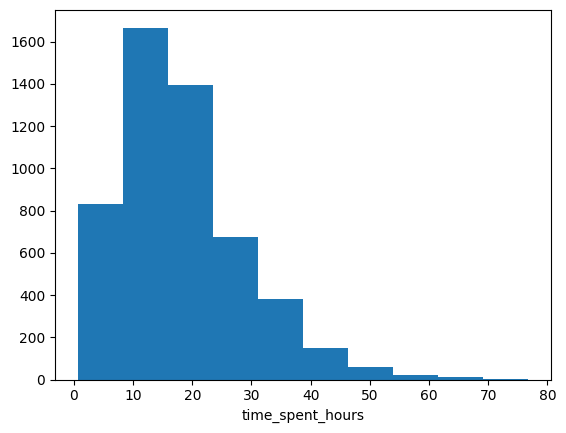

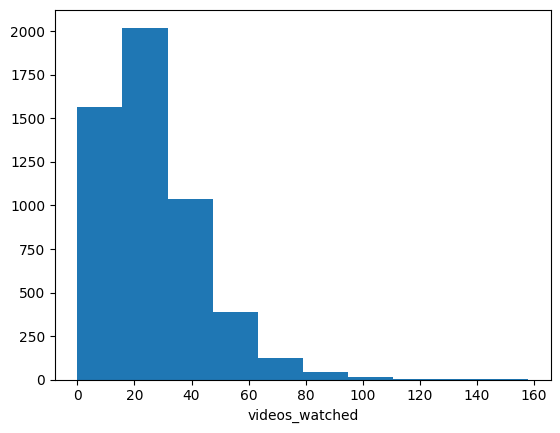

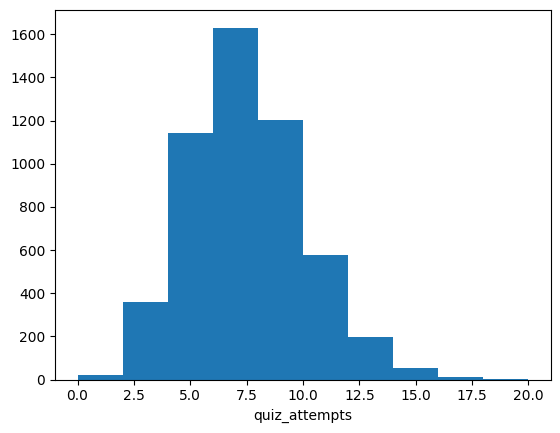

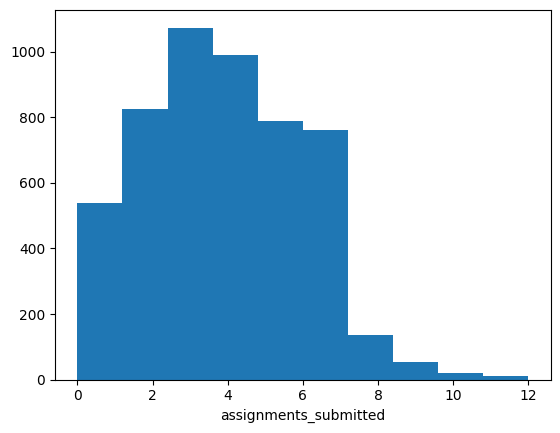

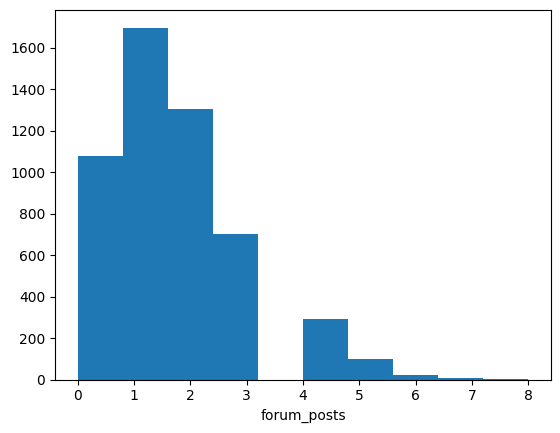

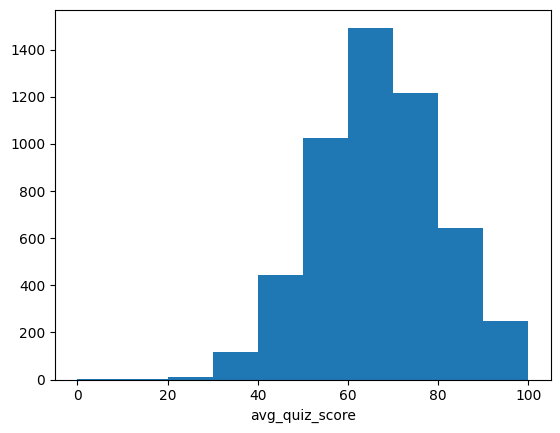

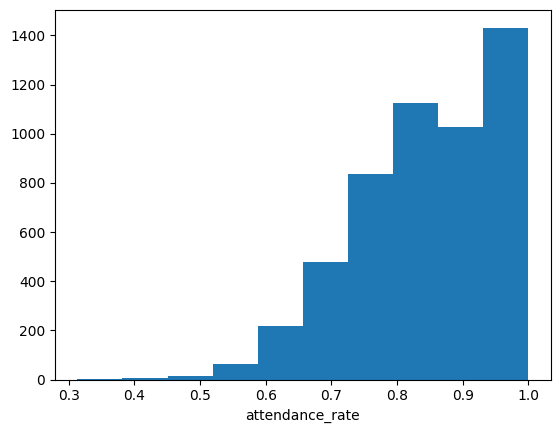

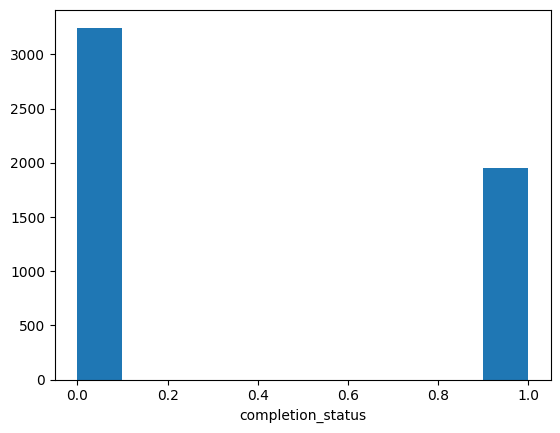

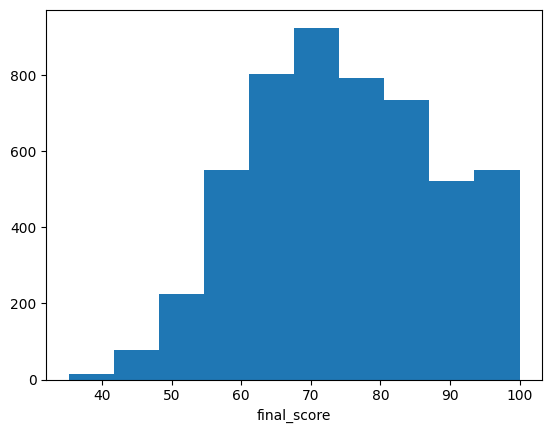

In [99]:
for cols in num_cols:
    plt.hist(df[cols])
    plt.xlabel(cols)
    plt.show()

## Check Outlier

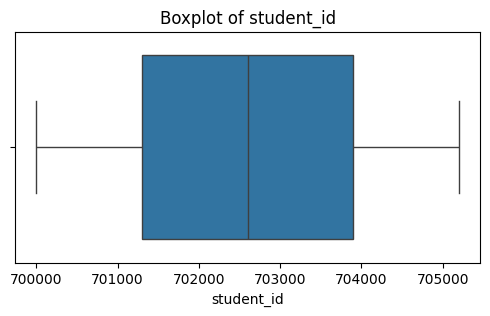

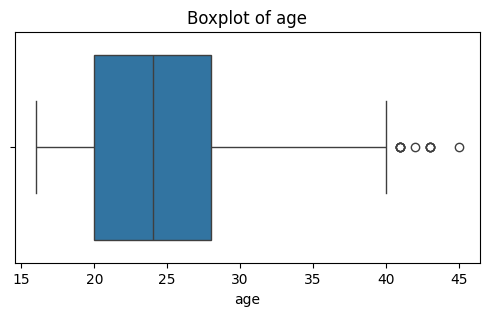

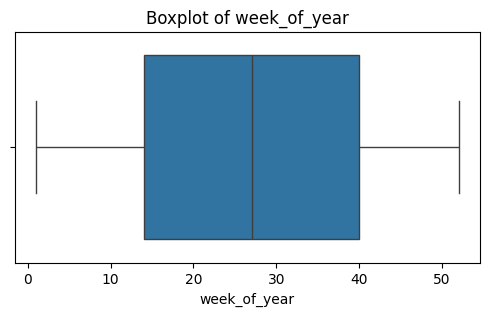

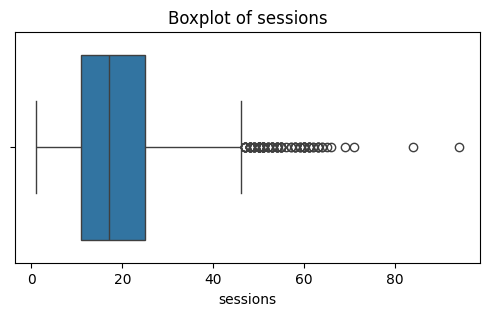

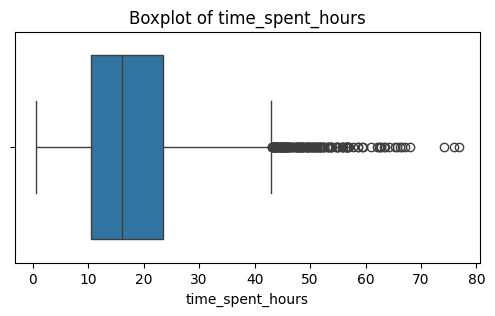

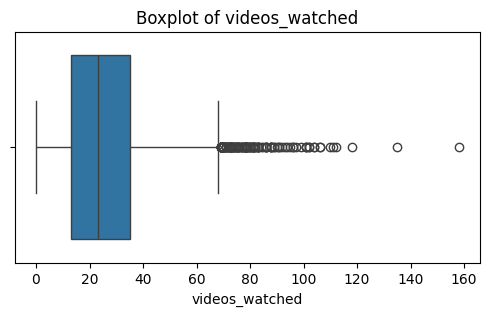

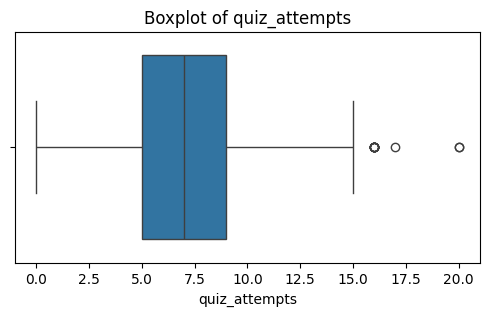

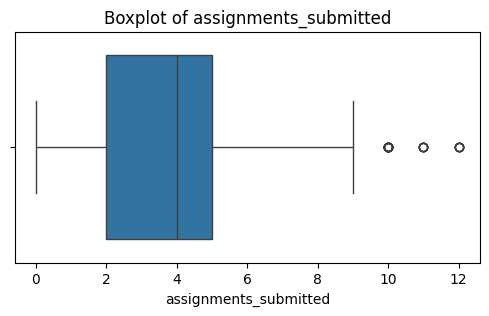

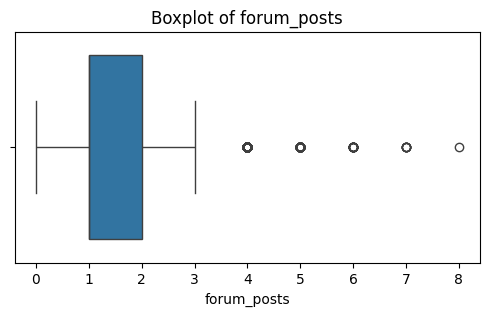

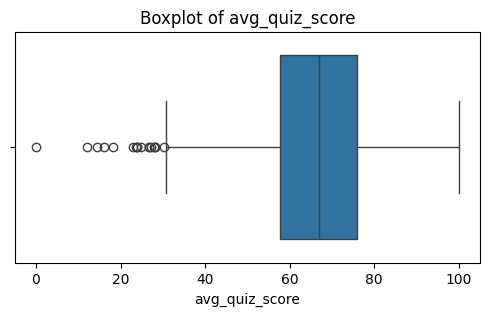

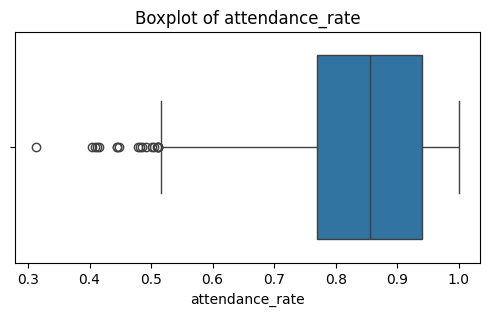

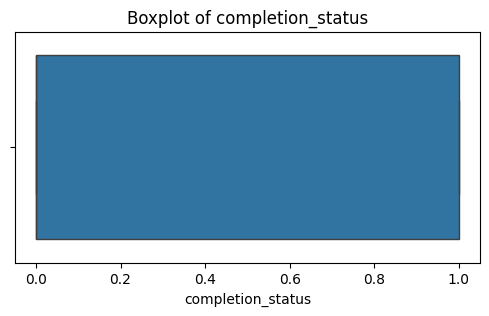

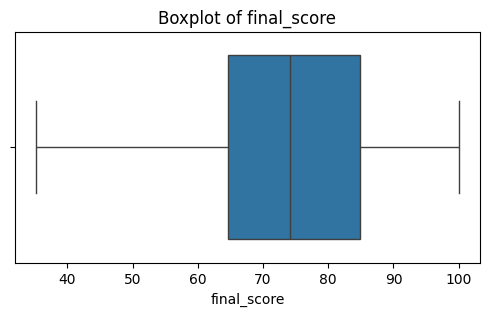

In [100]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [101]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

student_id: 0 outliers
age: 11 outliers
week_of_year: 0 outliers
sessions: 107 outliers
time_spent_hours: 149 outliers
videos_watched: 138 outliers
quiz_attempts: 12 outliers
assignments_submitted: 30 outliers
forum_posts: 418 outliers
avg_quiz_score: 17 outliers
attendance_rate: 18 outliers
completion_status: 0 outliers
final_score: 0 outliers


### Handle Outlier Using IQR

In [102]:
for cols in num_cols:

    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)

    IQR = Q3 - Q1

    Lower = Q1 - (1.5 * IQR)
    Upper = Q3 + (1.5 * IQR)

    df[cols] = df[cols].clip(Lower, Upper)

print("Outliers Treated Successfully")

Outliers Treated Successfully


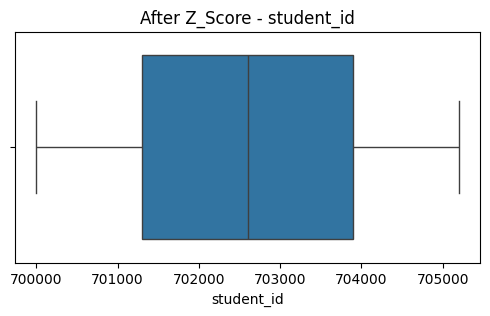

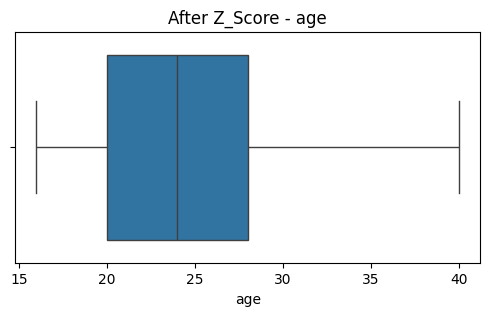

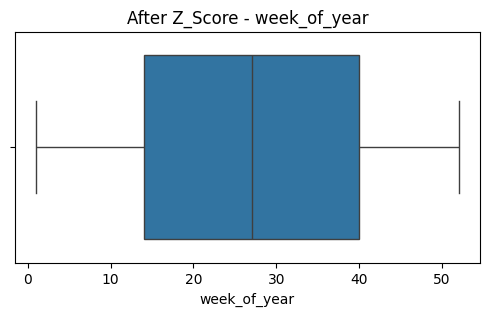

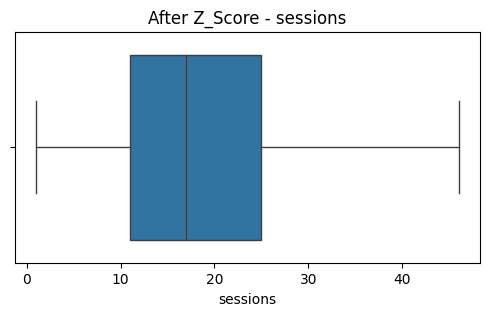

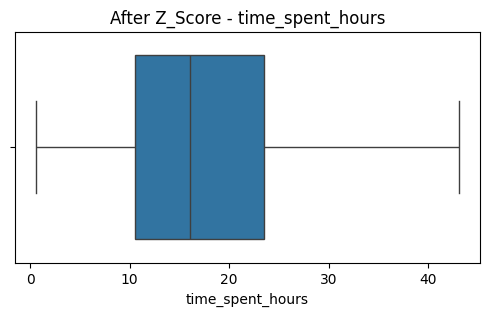

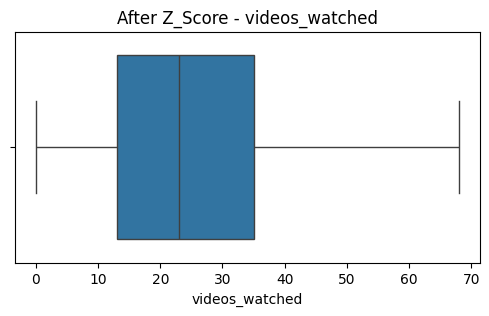

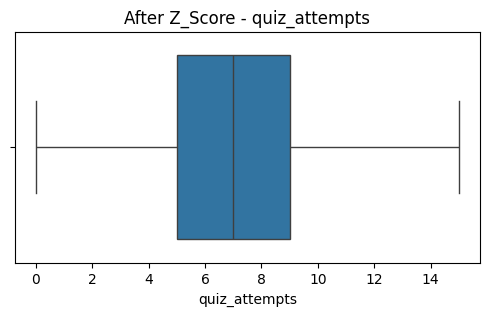

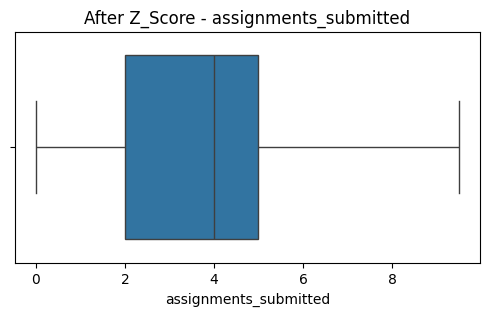

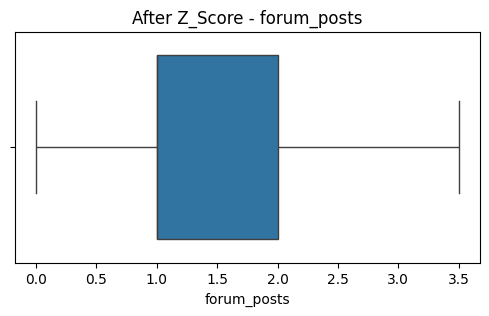

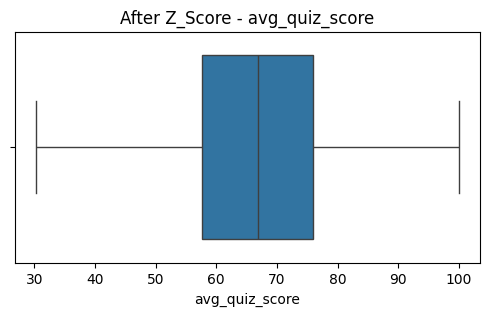

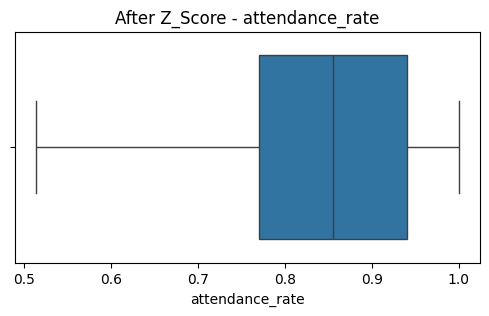

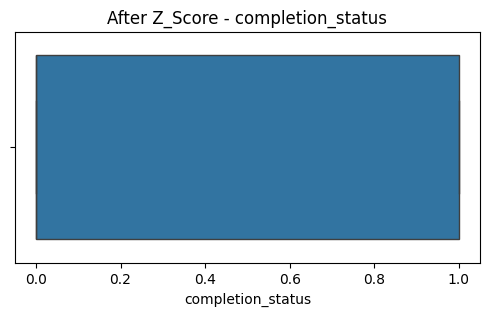

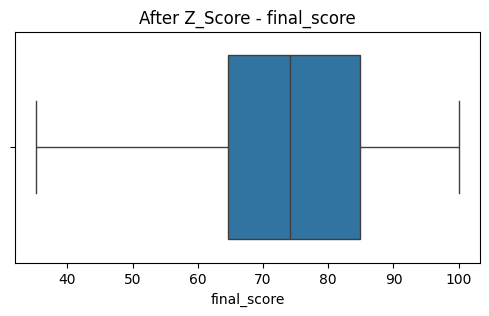

In [103]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'After Z_Score - {col}')
    plt.show()

In [104]:
df.drop(['student_id','course_start_date'],axis=1,inplace=True)
df.head(5)

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,Europe,Laptop,Undergrad,Intermediate,Business,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,Europe,Laptop,Undergrad,Intermediate,Programming,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,Europe,Mobile,Graduate,Advanced,Programming,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,Asia,Mobile,Undergrad,Beginner,Design,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,Asia,Tablet,WorkingPro,Advanced,Business,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


In [105]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

C:\Users\Shyamdev verma\AppData\Local\Temp\ipykernel_4244\1748023237.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


In [106]:
X = df.drop(["completion_status","final_score"], axis=1)

y_class = df["completion_status"]

y_reg = df["final_score"]

In [107]:
df

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,28.0,2,2,3,0,1,35.0,27.0,26.1,28.0,7.0,8.0,1.0,77.2,0.897,1.0,97.4
5196,28.0,0,2,0,1,2,17.0,21.0,3.9,31.0,8.0,4.0,0.0,82.4,0.743,1.0,71.9
5197,22.0,2,0,2,2,3,31.0,32.0,12.8,43.0,7.0,2.0,0.0,62.4,0.757,1.0,71.5
5198,25.0,2,0,0,1,4,3.0,16.0,27.1,21.0,5.0,8.0,2.0,76.1,0.847,0.0,86.8


## Scalling Data

In [108]:
scaler = StandardScaler()


In [ ]:
scale_cols = scaler.fit_transform(X)

X_scaled = pd.DataFrame(scale_cols, columns=X.columns)
print("Scaling Completed")


Scaling Completed


In [110]:
X_scaled.head(5)

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate
0,1.377570,1.118940,-1.249103,0.388229,1.072902,-1.341660,-0.974361,-1.771548,-1.044399,-1.479363,-0.388491,-1.464480,-0.462495,-0.996464,-1.718295
1,-1.318262,1.118940,-1.249103,0.388229,1.072902,1.367712,0.491691,-0.290368,0.935191,-1.177419,-1.171952,1.640424,-0.462495,-1.128639,1.361345
2,0.119515,1.118940,0.435372,-1.611563,-1.727846,1.367712,0.824885,-1.277821,-1.094899,-0.573531,-1.955413,-0.946996,-1.361886,-0.342935,-0.334689
3,0.299237,0.165715,0.435372,0.388229,-0.327472,0.013026,-1.107638,1.487047,0.420094,1.902410,0.786700,1.122940,-1.361886,-0.555883,0.245534
4,0.299237,0.165715,2.119847,1.388124,-1.727846,-1.341660,-0.974361,0.302104,1.450289,0.936189,0.786700,-0.946996,-1.361886,-0.129988,-0.298983


In [112]:
df

,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5195,28.0,2,2,3,0,1,35.0,27.0,26.1,28.0,7.0,8.0,1.0,77.2,0.897,1.0,97.4
5196,28.0,0,2,0,1,2,17.0,21.0,3.9,31.0,8.0,4.0,0.0,82.4,0.743,1.0,71.9
5197,22.0,2,0,2,2,3,31.0,32.0,12.8,43.0,7.0,2.0,0.0,62.4,0.757,1.0,71.5
5198,25.0,2,0,0,1,4,3.0,16.0,27.1,21.0,5.0,8.0,2.0,76.1,0.847,0.0,86.8


In [113]:
print("Final Shape :", df.shape)

df.head(5)

Final Shape : (5200, 17)


,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,32.0,3,0,2,2,0,12.0,1.0,7.6,1.0,6.0,1.0,1.0,53.3,0.655,0.0,49.8
1,17.0,3,0,2,2,4,34.0,16.0,27.2,6.0,4.0,7.0,1.0,51.5,1.000,1.0,84.0
2,25.0,3,1,0,0,4,39.0,6.0,7.1,16.0,2.0,2.0,0.0,62.2,0.810,0.0,62.5
3,26.0,2,1,2,1,2,10.0,34.0,22.1,57.0,9.0,6.0,0.0,59.3,0.875,1.0,89.5
4,26.0,2,2,3,0,0,12.0,22.0,32.3,41.0,9.0,2.0,0.0,65.1,0.814,0.0,67.4


In [118]:
df.to_csv("clean_data.csv",index=False)